In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
import os
import warnings
warnings.filterwarnings('ignore')

# Load data
file_path = r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Data\SorgesData.xlsx"
df = pd.read_excel(file_path)

print(f"Data loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst rows:\n{df.head()}")

Data loaded: (370, 55)
Columns: ['Sample', 'D', 'O', 'Sp', 'Cond', 'Order', 'Year', 'Unnamed: 7', 'Unnamed: 8', 'Conditions Total', 'Unnamed: 10', 'MeanO', 'MeanH', 'Error O', 'Error H', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54']

First rows:
   Sample           D          O        Sp    Cond  Order  Year  Unnamed: 7  \
0  S-FO-1  -98.797599  24.340408  Fraxinus  Living      0     1         NaN   
1  S-FO-2  -95.081829  22.504079  Fraxinus

In [2]:
# Explore data categories
print("Unique species:")
print(df['Sp'].unique())
print(f"\nSpecies counts:\n{df['Sp'].value_counts()}")

print("\n" + "="*50)
print("Unique conditions:")
print(df['Cond'].unique())
print(f"\nCondition counts:\n{df['Cond'].value_counts()}")

print("\n" + "="*50)
print("Species x Condition crosstab:")
print(pd.crosstab(df['Sp'], df['Cond']))

Unique species:
['Fraxinus' 'Alnus']

Species counts:
Sp
Alnus       190
Fraxinus    180
Name: count, dtype: int64

Unique conditions:
['Living' 'Float' 'Out' 'Sub']

Condition counts:
Cond
Out       160
Float     150
Sub        40
Living     20
Name: count, dtype: int64

Species x Condition crosstab:
Cond      Float  Living  Out  Sub
Sp                               
Alnus        80      10   80   20
Fraxinus     70      10   80   20


In [3]:
# Create 6 groups: Sp (Fraxinus, Alnus) + Living + Condition (Float, Out, Sub)
grupos = {
    'Fraxinus_Living_Float': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Float']))],
    'Fraxinus_Living_Out': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Out']))],
    'Fraxinus_Living_Sub': df[(df['Sp'] == 'Fraxinus') & (df['Cond'].isin(['Living', 'Sub']))],
    'Alnus_Living_Float': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Float']))],
    'Alnus_Living_Out': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Out']))],
    'Alnus_Living_Sub': df[(df['Sp'] == 'Alnus') & (df['Cond'].isin(['Living', 'Sub']))]
}

print("\n" + "="*70)
print("6 GROUPS CREATED")
print("="*70)

for nombre, grupo_df in grupos.items():
    print(f"\n{nombre}: {len(grupo_df)} samples")
    print(f"  D: {grupo_df['D'].mean():.2f} ± {grupo_df['D'].std():.2f}")
    print(f"  O: {grupo_df['O'].mean():.2f} ± {grupo_df['O'].std():.2f}")


6 GROUPS CREATED

Fraxinus_Living_Float: 80 samples
  D: -87.61 ± 9.30
  O: 22.14 ± 1.48

Fraxinus_Living_Out: 90 samples
  D: -93.13 ± 9.36
  O: 22.26 ± 1.30

Fraxinus_Living_Sub: 30 samples
  D: -88.06 ± 10.41
  O: 23.63 ± 1.82

Alnus_Living_Float: 90 samples
  D: -101.04 ± 4.73
  O: 21.33 ± 0.94

Alnus_Living_Out: 90 samples
  D: -103.48 ± 6.04
  O: 20.69 ± 1.49

Alnus_Living_Sub: 30 samples
  D: -105.57 ± 5.57
  O: 21.80 ± 1.01


In [4]:
# Mann-Kendall test for each group
print("\n" + "="*100)
print("MANN-KENDALL TEST: ONE TEST PER GROUP")
print("="*100)

mk_results = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    # Calculate mean D and O for each Order
    time_series = grupo_df.groupby('Order')[['D', 'O']].mean().reset_index().sort_values('Order')
    time_points = time_series['Order'].values
    mean_d = time_series['D'].values
    mean_o = time_series['O'].values
    n_timepoints = len(time_series)
    
    print(f"  Time points: {n_timepoints} Orders")
    print(f"  Orders: {sorted([int(x) for x in time_points])}")
    
    # Apply Mann-Kendall test
    time_indices = np.arange(n_timepoints)
    tau_d, p_d = kendalltau(time_indices, mean_d)
    tau_o, p_o = kendalltau(time_indices, mean_o)
    
    trend_d = "Increasing" if tau_d > 0 else "Decreasing"
    sig_d = "***" if p_d < 0.05 else "NS"
    trend_o = "Increasing" if tau_o > 0 else "Decreasing"
    sig_o = "***" if p_o < 0.05 else "NS"
    
    print(f"  D: τ={tau_d:.4f}, p={p_d:.4f} ({trend_d}, {sig_d})")
    print(f"  O: τ={tau_o:.4f}, p={p_o:.4f} ({trend_o}, {sig_o})")
    
    mk_results[nombre_grupo] = {
        'n_timepoints': n_timepoints,
        'D_tau': tau_d, 'D_pval': p_d, 'D_trend': trend_d,
        'O_tau': tau_o, 'O_pval': p_o, 'O_trend': trend_o
    }


MANN-KENDALL TEST: ONE TEST PER GROUP

Fraxinus_Living_Float:
  Time points: 8 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7]
  D: τ=0.1429, p=0.7195 (Increasing, NS)
  O: τ=-0.7143, p=0.0141 (Decreasing, ***)

Fraxinus_Living_Out:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=-0.0556, p=0.9195 (Decreasing, NS)
  O: τ=-0.6667, p=0.0127 (Decreasing, ***)

Fraxinus_Living_Sub:
  Time points: 3 Orders
  Orders: [0, 1, 3]
  D: τ=0.3333, p=1.0000 (Increasing, NS)
  O: τ=-0.3333, p=1.0000 (Decreasing, NS)

Alnus_Living_Float:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=0.0556, p=0.9195 (Increasing, NS)
  O: τ=-0.3333, p=0.2595 (Decreasing, NS)

Alnus_Living_Out:
  Time points: 9 Orders
  Orders: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  D: τ=-0.2222, p=0.4767 (Decreasing, NS)
  O: τ=-0.7222, p=0.0059 (Decreasing, ***)

Alnus_Living_Sub:
  Time points: 3 Orders
  Orders: [0, 1, 3]
  D: τ=-0.3333, p=1.0000 (Decreasing, NS)
  O: τ=-0.3333, p=1.0000 (Decreasing, N

In [5]:
# Descriptive statistics: mean and std by Order for each group
print("\n" + "="*100)
print("DESCRIPTIVE STATISTICS: MEAN AND STD BY ORDER")
print("="*100)

descriptive_stats = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    stats_by_order = grupo_df.groupby('Order')[['D', 'O']].agg(['mean', 'std', 'count']).reset_index().sort_values('Order')
    stats_by_order.columns = ['Order', 'D_mean', 'D_std', 'D_count', 'O_mean', 'O_std', 'O_count']
    
    print(f"{'Order':<8} {'N':<6} {'D_mean':<14} {'D_std':<14} {'O_mean':<14} {'O_std':<14}")
    for idx, row in stats_by_order.iterrows():
        print(f"{int(row['Order']):<8} {int(row['D_count']):<6} {row['D_mean']:<14.4f} {row['D_std']:<14.4f} {row['O_mean']:<14.4f} {row['O_std']:<14.4f}")
    
    descriptive_stats[nombre_grupo] = stats_by_order


DESCRIPTIVE STATISTICS: MEAN AND STD BY ORDER

Fraxinus_Living_Float:
Order    N      D_mean         D_std          O_mean         O_std         
0        10     -99.3528       6.0812         23.8422        0.9612        
1        10     -81.6943       5.9972         23.2698        1.7349        
2        10     -90.3725       6.7717         21.8207        0.7377        
3        10     -84.0564       5.4691         22.1749        0.7806        
4        10     -84.8751       6.6413         22.1702        0.9090        
5        9      -92.2351       8.2363         20.6149        1.0292        
6        10     -86.6529       6.4621         21.5939        0.9833        
7        10     -82.1368       13.2829        21.4972        1.7954        

Fraxinus_Living_Out:
Order    N      D_mean         D_std          O_mean         O_std         
0        10     -99.3528       6.0812         23.8422        0.9612        
1        10     -87.1830       5.4178         23.8580        1.1834    

In [6]:
# Group-level extremes: find max/min for each group and calculate deviations
print("\n" + "="*100)
print("GROUP-LEVEL EXTREMES ANALYSIS")
print("="*100)

group_extremes = {}

for nombre_grupo, grupo_df in grupos.items():
    print(f"\n{nombre_grupo}:")
    
    # Get time series for this group
    time_series = grupo_df.groupby('Order')[['D', 'O']].mean().reset_index().sort_values('Order')
    mean_d_values = time_series['D'].values
    mean_o_values = time_series['O'].values
    orders = time_series['Order'].values
    
    # Get baseline (Order 0)
    baseline_d = time_series[time_series['Order'] == 0]['D'].values[0]
    baseline_o = time_series[time_series['Order'] == 0]['O'].values[0]
    
    print(f"  Baseline (Order 0): D={baseline_d:.4f}, O={baseline_o:.4f}")
    
    # Find extremes
    max_d_idx = np.argmax(mean_d_values)
    min_d_idx = np.argmin(mean_d_values)
    max_o_idx = np.argmax(mean_o_values)
    min_o_idx = np.argmin(mean_o_values)
    
    max_d_val = mean_d_values[max_d_idx]
    max_d_ord = int(orders[max_d_idx])
    max_d_dev = max_d_val - baseline_d
    
    min_d_val = mean_d_values[min_d_idx]
    min_d_ord = int(orders[min_d_idx])
    min_d_dev = min_d_val - baseline_d
    
    max_o_val = mean_o_values[max_o_idx]
    max_o_ord = int(orders[max_o_idx])
    max_o_dev = max_o_val - baseline_o
    
    min_o_val = mean_o_values[min_o_idx]
    min_o_ord = int(orders[min_o_idx])
    min_o_dev = min_o_val - baseline_o
    
    print(f"  D MAX: Order {max_d_ord}, Value={max_d_val:.4f}, Deviation={max_d_dev:+.4f}")
    print(f"  D MIN: Order {min_d_ord}, Value={min_d_val:.4f}, Deviation={min_d_dev:+.4f}")
    print(f"  O MAX: Order {max_o_ord}, Value={max_o_val:.4f}, Deviation={max_o_dev:+.4f}")
    print(f"  O MIN: Order {min_o_ord}, Value={min_o_val:.4f}, Deviation={min_o_dev:+.4f}")
    
    group_extremes[nombre_grupo] = {
        'Baseline_D': baseline_d, 'Baseline_O': baseline_o,
        'Max_D_val': max_d_val, 'Max_D_ord': max_d_ord, 'Max_D_dev': max_d_dev,
        'Min_D_val': min_d_val, 'Min_D_ord': min_d_ord, 'Min_D_dev': min_d_dev,
        'Max_O_val': max_o_val, 'Max_O_ord': max_o_ord, 'Max_O_dev': max_o_dev,
        'Min_O_val': min_o_val, 'Min_O_ord': min_o_ord, 'Min_O_dev': min_o_dev
    }


GROUP-LEVEL EXTREMES ANALYSIS

Fraxinus_Living_Float:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 1, Value=-81.6943, Deviation=+17.6586
  D MIN: Order 0, Value=-99.3528, Deviation=+0.0000
  O MAX: Order 0, Value=23.8422, Deviation=+0.0000
  O MIN: Order 5, Value=20.6149, Deviation=-3.2273

Fraxinus_Living_Out:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 2, Value=-81.3664, Deviation=+17.9864
  D MIN: Order 8, Value=-101.3509, Deviation=-1.9980
  O MAX: Order 1, Value=23.8580, Deviation=+0.0158
  O MIN: Order 7, Value=21.4395, Deviation=-2.4026

Fraxinus_Living_Sub:
  Baseline (Order 0): D=-99.3528, O=23.8422
  D MAX: Order 1, Value=-81.8407, Deviation=+17.5122
  D MIN: Order 0, Value=-99.3528, Deviation=+0.0000
  O MAX: Order 1, Value=24.5264, Deviation=+0.6842
  O MIN: Order 3, Value=22.5291, Deviation=-1.3131

Alnus_Living_Float:
  Baseline (Order 0): D=-102.5445, O=21.7779
  D MAX: Order 3, Value=-95.6276, Deviation=+6.9170
  D MIN: Order 5, Value=-104.

In [7]:
# Export all results to Excel
output_dir = r"C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Results"
os.makedirs(output_dir, exist_ok=True)

print("\n" + "="*100)
print("EXPORTING RESULTS TO EXCEL")
print("="*100)

# 1. Mann-Kendall results
mk_data = []
for nombre, result in mk_results.items():
    mk_data.append({
        'Group': nombre, 'Variable': 'D', 'N': result['n_timepoints'],
        'Kendall_tau': result['D_tau'], 'p_value': result['D_pval'], 'Trend': result['D_trend']
    })
    mk_data.append({
        'Group': nombre, 'Variable': 'O', 'N': result['n_timepoints'],
        'Kendall_tau': result['O_tau'], 'p_value': result['O_pval'], 'Trend': result['O_trend']
    })
mk_df = pd.DataFrame(mk_data)

# 2. Group extremes
extreme_data = []
for nombre, result in group_extremes.items():
    extreme_data.append({
        'Group': nombre, 'Variable': 'D', 'Type': 'MAX',
        'Value': result['Max_D_val'], 'Order': result['Max_D_ord'], 'Deviation': result['Max_D_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'D', 'Type': 'MIN',
        'Value': result['Min_D_val'], 'Order': result['Min_D_ord'], 'Deviation': result['Min_D_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'O', 'Type': 'MAX',
        'Value': result['Max_O_val'], 'Order': result['Max_O_ord'], 'Deviation': result['Max_O_dev']
    })
    extreme_data.append({
        'Group': nombre, 'Variable': 'O', 'Type': 'MIN',
        'Value': result['Min_O_val'], 'Order': result['Min_O_ord'], 'Deviation': result['Min_O_dev']
    })
extreme_df = pd.DataFrame(extreme_data)

# Write to Excel with multiple sheets
with pd.ExcelWriter(os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx'), engine='openpyxl') as writer:
    mk_df.to_excel(writer, sheet_name='Mann-Kendall', index=False)
    extreme_df.to_excel(writer, sheet_name='Group-Extremes', index=False)
    for nombre, stats_df in descriptive_stats.items():
        sheet_name = nombre[:31]  # Excel limit
        stats_df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"\n✓ File saved: {os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx')}")
print("\nSheets created:")
print("  1. Mann-Kendall: Test results for each group")
print("  2. Group-Extremes: Max/min values and deviations for each group")
print(f"  3-8. Group statistics: Descriptive stats by Order for each group")


EXPORTING RESULTS TO EXCEL

✓ File saved: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\Arve-Valserine\Isotopes\GitHub Isotopes\Results\Isotope_Analysis_Complete2.xlsx

Sheets created:
  1. Mann-Kendall: Test results for each group
  2. Group-Extremes: Max/min values and deviations for each group
  3-8. Group statistics: Descriptive stats by Order for each group



Fraxinus:
  Float: n=70, δD=-85.91±8.44‰, δ¹⁸O=21.90±1.38‰
  Out: n=80, δD=-92.35±9.43‰, δ¹⁸O=22.07±1.20‰
  Sub: n=20, δD=-82.41±6.88‰, δ¹⁸O=23.53±2.14‰
  Living: n=10, δD=-99.35±6.08‰, δ¹⁸O=23.84±0.96‰

Alnus:
  Float: n=80, δD=-100.85±4.82‰, δ¹⁸O=21.28±0.96‰
  Out: n=80, δD=-103.60±6.28‰, δ¹⁸O=20.56±1.51‰
  Sub: n=20, δD=-107.08±5.77‰, δ¹⁸O=21.82±1.15‰
  Living: n=10, δD=-102.54±3.78‰, δ¹⁸O=21.78±0.69‰


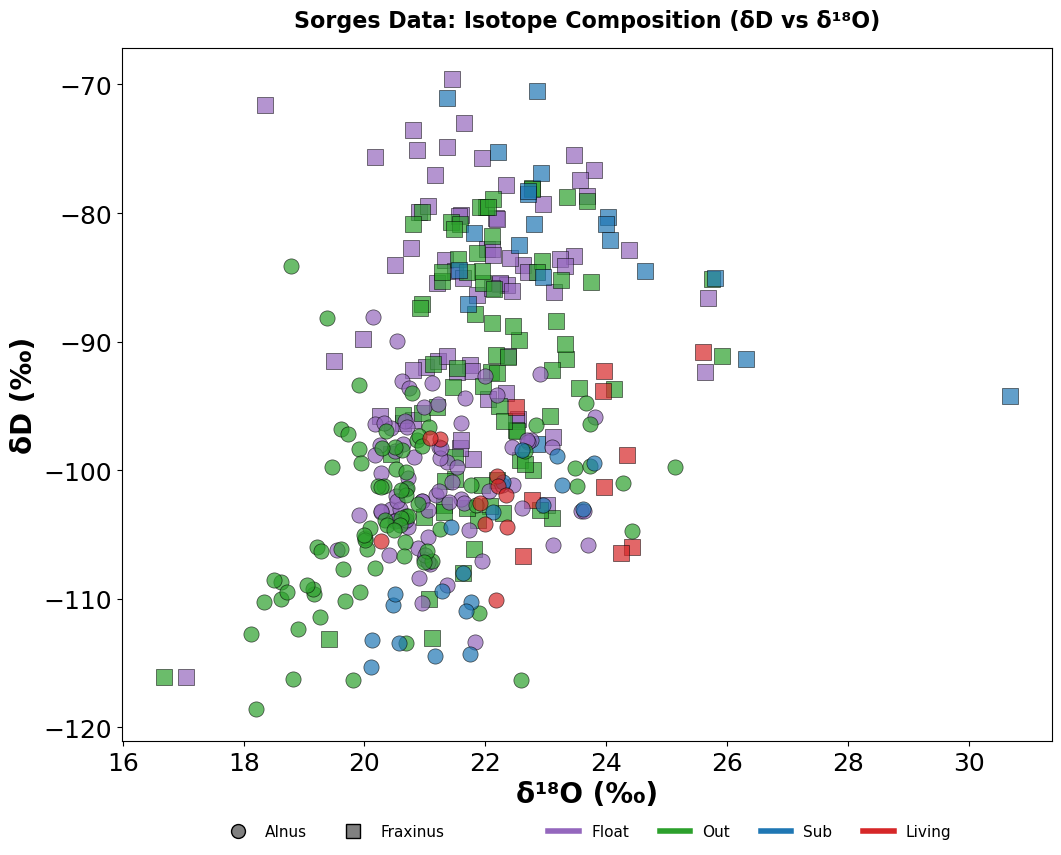

In [8]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Create figure with single plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot data for each species and condition combination
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            ax.scatter(condition_data['O'], condition_data['D'], 
                      marker=marker_styles[species], s=120, 
                      c=condition_colors[condition], 
                      alpha=0.7, edgecolors='black', linewidth=0.5)

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Isotope Composition (δD vs δ¹⁸O)', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid(True, alpha=0, linestyle='--')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Alnus', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Fraxinus', markeredgecolor='black'))

legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line for spacing

# Add condition colors
legend_elements.append(Line2D([0], [0], color='#9467bd', linewidth=4, label='Float'))
legend_elements.append(Line2D([0], [0], color='#2ca02c', linewidth=4, label='Out'))
legend_elements.append(Line2D([0], [0], color='#1f77b4', linewidth=4, label='Sub'))
legend_elements.append(Line2D([0], [0], color='#d62728', linewidth=4, label='Living'))

ax.legend(handles=legend_elements, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=7, frameon=False)
print(f"{'='*60}")
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    print(f"\n{species}:")
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        if len(condition_data) > 0:
            print(f"  {condition}: n={len(condition_data)}, δD={condition_data['D'].mean():.2f}±{condition_data['D'].std():.2f}‰, δ¹⁸O={condition_data['O'].mean():.2f}±{condition_data['O'].std():.2f}‰")

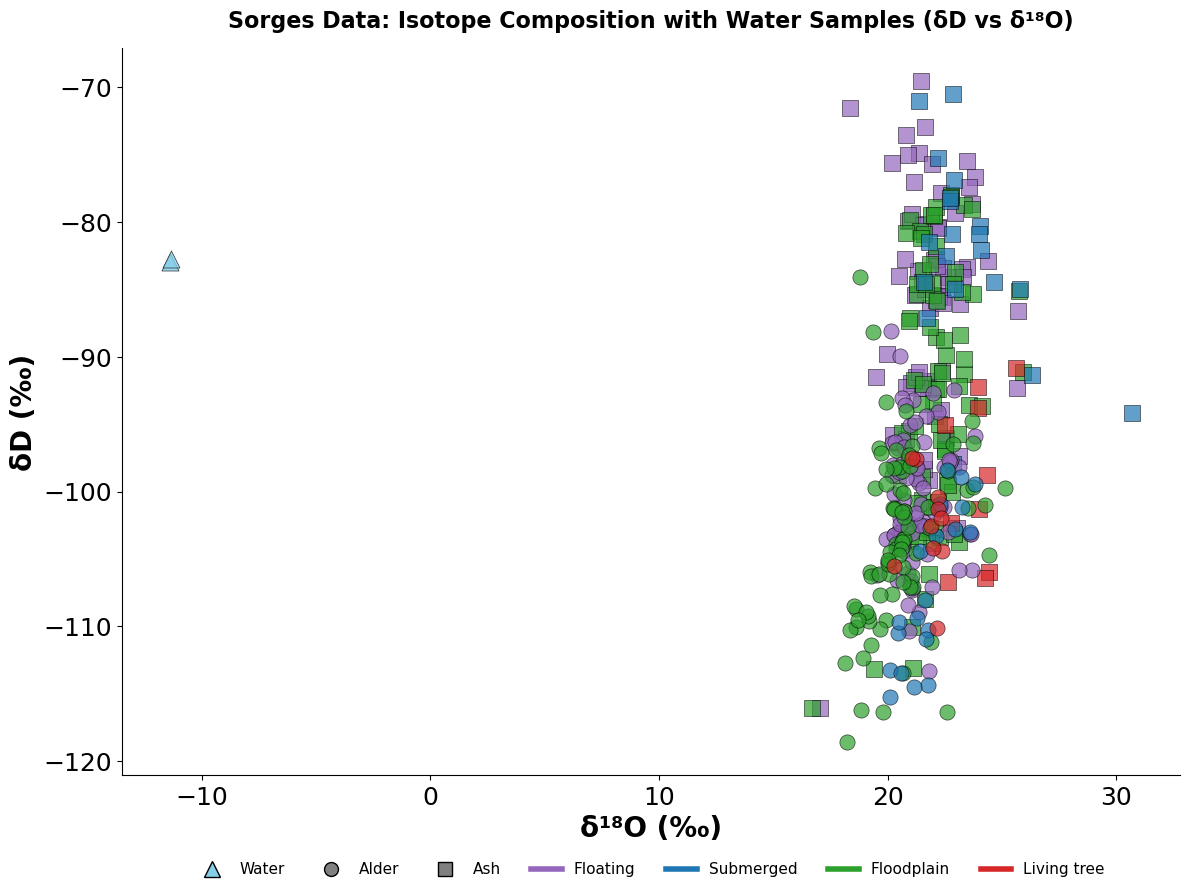


Isotope Scatter Plot with Water Samples - Summary

Fraxinus:
  Float: n=70, δD=-85.91±8.44‰, δ¹⁸O=21.90±1.38‰
  Out: n=80, δD=-92.35±9.43‰, δ¹⁸O=22.07±1.20‰
  Sub: n=20, δD=-82.41±6.88‰, δ¹⁸O=23.53±2.14‰
  Living: n=10, δD=-99.35±6.08‰, δ¹⁸O=23.84±0.96‰

Alnus:
  Float: n=80, δD=-100.85±4.82‰, δ¹⁸O=21.28±0.96‰
  Out: n=80, δD=-103.60±6.28‰, δ¹⁸O=20.56±1.51‰
  Sub: n=20, δD=-107.08±5.77‰, δ¹⁸O=21.82±1.15‰
  Living: n=10, δD=-102.54±3.78‰, δ¹⁸O=21.78±0.69‰

Water Samples:
  Sorges-M.1: δ¹⁸O=-11.39‰, δD=-83.00‰
  Sorges-M.2: δ¹⁸O=-11.33‰, δD=-82.80‰


In [9]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Water samples data
water_samples = [
    {'name': 'Sorges-M.1', 'O': -11.39, 'D': -83.0},
    {'name': 'Sorges-M.2', 'O': -11.33, 'D': -82.8}
]

# Create figure with single plot
fig, ax = plt.subplots(figsize=(12, 9))

# Plot data for each species and condition combination
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            ax.scatter(condition_data['O'], condition_data['D'], 
                      marker=marker_styles[species], s=120, 
                      c=condition_colors[condition], 
                      alpha=0.7, edgecolors='black', linewidth=0.5)

# Plot water samples
water_o = [sample['O'] for sample in water_samples]
water_d = [sample['D'] for sample in water_samples]
ax.scatter(water_o, water_d, 
          marker='^', s=150, 
          c='#87CEEB',  # Light blue
          label='Water', 
          alpha=0.8, edgecolors='black', linewidth=0.5)

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Isotope Composition with Water Samples (δD vs δ¹⁸O)', fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add water marker first
legend_elements.append(Line2D([0], [0], marker='^', color='w', markerfacecolor='#87CEEB', markersize=11, label='Water', markeredgecolor='black'))

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Alder', markeredgecolor='black'))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Ash', markeredgecolor='black'))

# Add condition colors
legend_elements.append(Line2D([0], [0], color='#9467bd', linewidth=4, label='Floating'))
legend_elements.append(Line2D([0], [0], color='#1f77b4', linewidth=4, label='Submerged'))
legend_elements.append(Line2D([0], [0], color='#2ca02c', linewidth=4, label='Floodplain'))
legend_elements.append(Line2D([0], [0], color='#d62728', linewidth=4, label='Living tree'))

ax.legend(handles=legend_elements, fontsize=11, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=8, frameon=False)

plt.tight_layout()
plt.show()

print(f"\nIsotope Scatter Plot with Water Samples - Summary")
print(f"{'='*60}")
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    print(f"\n{species}:")
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        if len(condition_data) > 0:
            print(f"  {condition}: n={len(condition_data)}, δD={condition_data['D'].mean():.2f}±{condition_data['D'].std():.2f}‰, δ¹⁸O={condition_data['O'].mean():.2f}±{condition_data['O'].std():.2f}‰")

print(f"\nWater Samples:")
for sample in water_samples:
    print(f"  {sample['name']}: δ¹⁸O={sample['O']:.2f}‰, δD={sample['D']:.2f}‰")

In [10]:
# Calculate statistics by Species, Condition and Order
print("\n" + "="*140)
print("STATISTICS BY SPECIES, CONDITION AND ORDER: MEAN, STD, AND SEM")
print("="*140)

# Get unique species and conditions
species_list = sorted(df['Sp'].unique())
conditions = sorted(df['Cond'].unique())

stats_by_sp_cond_order = {}

for species in species_list:
    print(f"\n{'='*140}")
    print(f"{species.upper()}")
    print(f"{'='*140}")
    
    species_data = df[df['Sp'] == species]
    
    for condition in conditions:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            print(f"\n  {condition.upper()}:")
            print(f"  {'Order':<10} {'N':<8} {'D_mean':<15} {'D_std':<15} {'D_SEM':<15} {'O_mean':<15} {'O_std':<15} {'O_SEM':<15}")
            print("  " + "-" * 135)
            
            # Group by Order
            stats_df = condition_data.groupby('Order').apply(
                lambda x: pd.Series({
                    'N': len(x),
                    'D_mean': x['D'].mean(),
                    'D_std': x['D'].std(),
                    'D_SEM': x['D'].std() / np.sqrt(len(x)),
                    'O_mean': x['O'].mean(),
                    'O_std': x['O'].std(),
                    'O_SEM': x['O'].std() / np.sqrt(len(x))
                })
            ).reset_index().sort_values('Order')
            
            # Print formatted table
            for idx, row in stats_df.iterrows():
                print(f"  {int(row['Order']):<10} {int(row['N']):<8} {row['D_mean']:<15.4f} {row['D_std']:<15.4f} {row['D_SEM']:<15.4f} {row['O_mean']:<15.4f} {row['O_std']:<15.4f} {row['O_SEM']:<15.4f}")
            
            stats_by_sp_cond_order[(species, condition)] = stats_df

# Create a consolidated dataframe for export
consolidated_data = []
for (species, condition), stats_df in stats_by_sp_cond_order.items():
    for idx, row in stats_df.iterrows():
        consolidated_data.append({
            'Species': species,
            'Condition': condition,
            'Order': int(row['Order']),
            'N': int(row['N']),
            'D_mean': row['D_mean'],
            'D_std': row['D_std'],
            'D_SEM': row['D_SEM'],
            'O_mean': row['O_mean'],
            'O_std': row['O_std'],
            'O_SEM': row['O_SEM']
        })

consolidated_df = pd.DataFrame(consolidated_data)

print("\n" + "="*140)
print("EXPORT TO EXCEL")
print("="*140)

# Add this consolidated data to the Excel file
output_path = os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx')

if os.path.exists(output_path):
    from openpyxl import load_workbook
    with pd.ExcelWriter(output_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        consolidated_df.to_excel(writer, sheet_name='Stats-by-Sp-Cond-Order', index=False)
    print(f"✓ Updated file: {output_path}")
    print(f"  Sheet 'Stats-by-Sp-Cond-Order' added with {len(consolidated_df)} records")
else:
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        consolidated_df.to_excel(writer, sheet_name='Stats-by-Sp-Cond-Order', index=False)
    print(f"✓ Created file: {output_path}")

print(f"\nSummary: {len(consolidated_df)} rows created ({len(species_list)} species × {len(conditions)} conditions)")



STATISTICS BY SPECIES, CONDITION AND ORDER: MEAN, STD, AND SEM

ALNUS

  FLOAT:
  Order      N        D_mean          D_std           D_SEM           O_mean          O_std           O_SEM          
  ---------------------------------------------------------------------------------------------------------------------------------------
  1          10       -100.8664       3.7015          1.1705          23.1472         0.5072          0.1604         
  2          10       -98.2498        3.4778          1.0998          21.2563         0.7377          0.2333         
  3          10       -95.6276        3.6674          1.1597          20.7080         0.4785          0.1513         
  4          10       -104.5852       3.7002          1.1701          21.3104         0.4198          0.1328         
  5          10       -104.8358       3.8210          1.2083          20.8531         0.4230          0.1338         
  6          10       -102.3019       3.4729          1.0982          20.

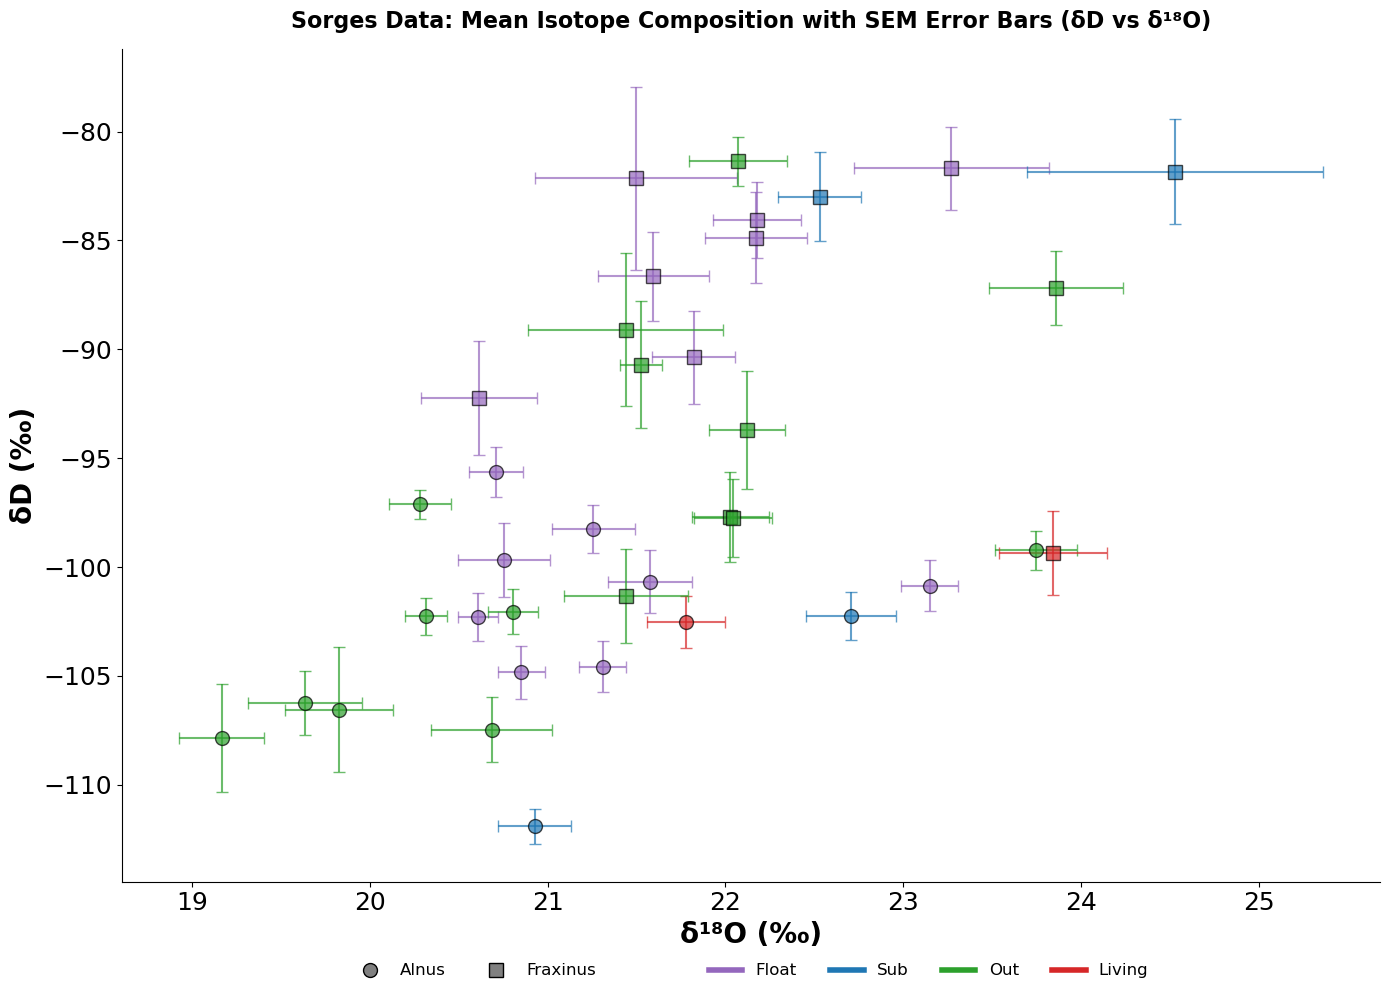


SCATTER PLOT OF MEANS WITH ERROR BARS (SEM)

Plot created successfully!
Total means plotted: 37

Note: Error bars represent Standard Error of the Mean (SEM)
Species-Condition combinations: 8


In [11]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Create figure for means with error bars
fig, ax = plt.subplots(figsize=(14, 10))

# Plot means for each species, condition, and order combination
for (species, condition), stats_df in stats_by_sp_cond_order.items():
    for idx, row in stats_df.iterrows():
        x = row['O_mean']
        y = row['D_mean']
        x_err = row['O_SEM']  # Using SEM for error bars
        y_err = row['D_SEM']
        
        marker = marker_styles[species]
        color = condition_colors[condition]
        
        # Plot point
        ax.errorbar(x, y, 
                   xerr=x_err, yerr=y_err,
                   marker=marker, markersize=10,
                   markerfacecolor=color, 
                   markeredgecolor='black', 
                   markeredgewidth=1,
                   color=color, 
                   alpha=0.7, 
                   linewidth=2,
                   capsize=4,
                   capthick=1.5,
                   elinewidth=1.5,
                   label=f"{species}-{condition}-O{int(row['Order'])}" if idx == 0 else "")

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Mean Isotope Composition with SEM Error Bars (δD vs δ¹⁸O)', 
             fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                             markersize=10, label='Alnus', markeredgecolor='black', markeredgewidth=1))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                             markersize=10, label='Fraxinus', markeredgecolor='black', markeredgewidth=1))

legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line for spacing

# Add condition colors
legend_elements.append(Line2D([0], [0], color='#9467bd', linewidth=4, label='Float'))
legend_elements.append(Line2D([0], [0], color='#1f77b4', linewidth=4, label='Sub'))
legend_elements.append(Line2D([0], [0], color='#2ca02c', linewidth=4, label='Out'))
legend_elements.append(Line2D([0], [0], color='#d62728', linewidth=4, label='Living'))

ax.legend(handles=legend_elements, fontsize=12, loc='upper center', 
          bbox_to_anchor=(0.5, -0.08), ncol=7, frameon=False)

plt.tight_layout()
plt.show()

print("\n" + "="*140)
print("SCATTER PLOT OF MEANS WITH ERROR BARS (SEM)")
print("="*140)
print("\nPlot created successfully!")
print(f"Total means plotted: {len(consolidated_df)}")
print(f"\nNote: Error bars represent Standard Error of the Mean (SEM)")
print(f"Species-Condition combinations: {len(stats_by_sp_cond_order)}")


In [12]:
# Calculate statistics by Species and Condition (all Orders combined)
print("\n" + "="*100)
print("STATISTICS BY SPECIES AND CONDITION: MEAN, STD, AND SEM (ALL ORDERS COMBINED)")
print("="*100)

species_list = sorted(df['Sp'].unique())
conditions = sorted(df['Cond'].unique())

stats_by_sp_cond = {}

print(f"\n{'Species':<15} {'Condition':<15} {'N':<8} {'D_mean':<15} {'D_std':<15} {'D_SEM':<15} {'O_mean':<15} {'O_std':<15} {'O_SEM':<15}")
print("-" * 120)

for species in species_list:
    species_data = df[df['Sp'] == species]
    
    for condition in conditions:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            N = len(condition_data)
            D_mean = condition_data['D'].mean()
            D_std = condition_data['D'].std()
            D_sem = D_std / np.sqrt(N)
            O_mean = condition_data['O'].mean()
            O_std = condition_data['O'].std()
            O_sem = O_std / np.sqrt(N)
            
            print(f"{species:<15} {condition:<15} {N:<8} {D_mean:<15.4f} {D_std:<15.4f} {D_sem:<15.4f} {O_mean:<15.4f} {O_std:<15.4f} {O_sem:<15.4f}")
            
            stats_by_sp_cond[(species, condition)] = {
                'N': N,
                'D_mean': D_mean,
                'D_std': D_std,
                'D_SEM': D_sem,
                'O_mean': O_mean,
                'O_std': O_std,
                'O_SEM': O_sem
            }

# Create a consolidated dataframe for export
consolidated_sp_cond_data = []
for (species, condition), stats_dict in stats_by_sp_cond.items():
    consolidated_sp_cond_data.append({
        'Species': species,
        'Condition': condition,
        'N': stats_dict['N'],
        'D_mean': stats_dict['D_mean'],
        'D_std': stats_dict['D_std'],
        'D_SEM': stats_dict['D_SEM'],
        'O_mean': stats_dict['O_mean'],
        'O_std': stats_dict['O_std'],
        'O_SEM': stats_dict['O_SEM']
    })

consolidated_sp_cond_df = pd.DataFrame(consolidated_sp_cond_data)

print("\n" + "="*100)
print("EXPORT TO EXCEL")
print("="*100)

# Add this consolidated data to the Excel file
output_path = os.path.join(output_dir, 'Isotope_Analysis_Complete2.xlsx')

if os.path.exists(output_path):
    from openpyxl import load_workbook
    with pd.ExcelWriter(output_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        consolidated_sp_cond_df.to_excel(writer, sheet_name='Stats-by-Sp-Cond', index=False)
    print(f"✓ Updated file: {output_path}")
    print(f"  Sheet 'Stats-by-Sp-Cond' added with {len(consolidated_sp_cond_df)} records")
else:
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        consolidated_sp_cond_df.to_excel(writer, sheet_name='Stats-by-Sp-Cond', index=False)
    print(f"✓ Created file: {output_path}")

print(f"\nSummary: {len(consolidated_sp_cond_df)} rows created ({len(species_list)} species × {len(conditions)} conditions)")



STATISTICS BY SPECIES AND CONDITION: MEAN, STD, AND SEM (ALL ORDERS COMBINED)

Species         Condition       N        D_mean          D_std           D_SEM           O_mean          O_std           O_SEM          
------------------------------------------------------------------------------------------------------------------------
Alnus           Float           80       -100.8525       4.8191          0.5388          21.2769         0.9598          0.1073         
Alnus           Living          10       -102.5445       3.7792          1.1951          21.7779         0.6886          0.2178         
Alnus           Out             80       -103.6013       6.2758          0.7017          20.5587         1.5112          0.1690         
Alnus           Sub             20       -107.0829       5.7719          1.2906          21.8163         1.1527          0.2578         
Fraxinus        Float           70       -85.9130        8.4356          1.0082          21.8957         1.3764   

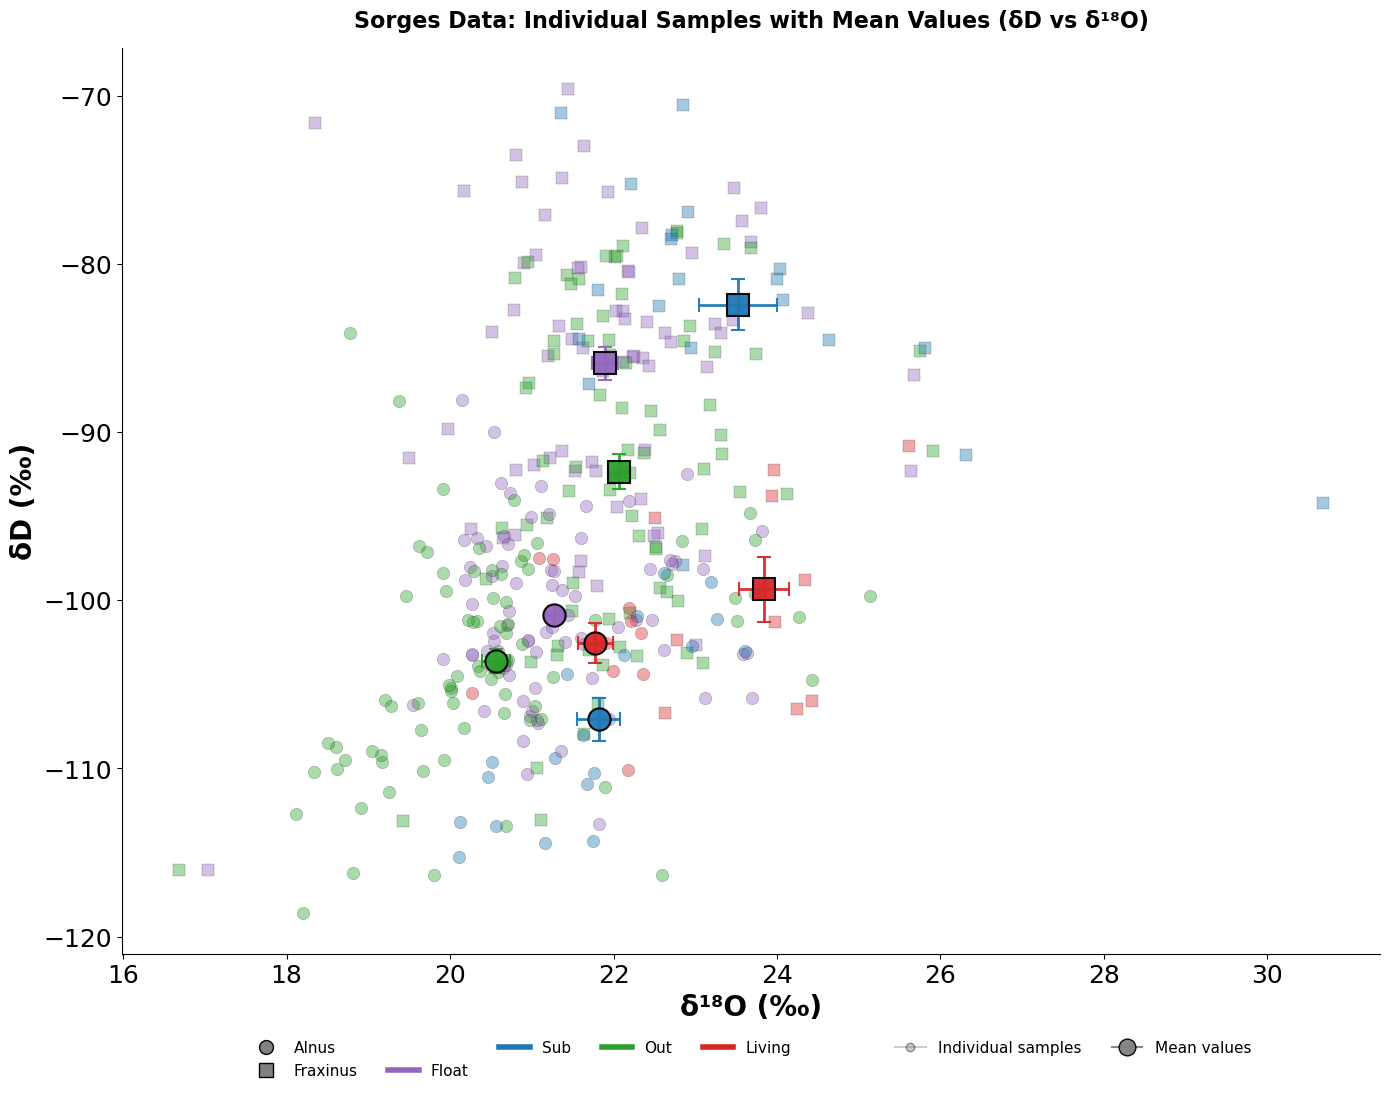


SCATTER PLOT: INDIVIDUAL SAMPLES WITH OVERLAID MEANS

Plot created successfully!
Individual samples plotted: 370
Mean values plotted: 8

Note: Error bars on means represent Standard Error of the Mean (SEM)
Individual samples are shown in light, transparent points
Mean values are shown in larger, opaque points with error bars


In [13]:
import matplotlib.pyplot as plt

# Define color mapping for conditions
condition_colors = {
    'Float': '#9467bd',  # Purple
    'Out': '#2ca02c',    # Green
    'Sub': '#1f77b4',    # Blue
    'Living': '#d62728'  # Red
}

# Define marker styles for species
marker_styles = {
    'Alnus': 'o',        # Circle
    'Fraxinus': 's'      # Square
}

# Create figure with all samples and means
fig, ax = plt.subplots(figsize=(14, 11))

# Plot all individual data points first (smaller, transparent)
for species in ['Fraxinus', 'Alnus']:
    species_data = df[df['Sp'] == species]
    
    for condition in ['Float', 'Out', 'Sub', 'Living']:
        condition_data = species_data[species_data['Cond'] == condition]
        
        if len(condition_data) > 0:
            ax.scatter(condition_data['O'], condition_data['D'], 
                      marker=marker_styles[species], s=80, 
                      c=condition_colors[condition], 
                      alpha=0.4, edgecolors='black', linewidth=0.3)

# Plot means for each species and condition (larger, opaque)
for (species, condition), stats_dict in stats_by_sp_cond.items():
    x = stats_dict['O_mean']
    y = stats_dict['D_mean']
    x_err = stats_dict['O_SEM']
    y_err = stats_dict['D_SEM']
    
    marker = marker_styles[species]
    color = condition_colors[condition]
    
    # Plot mean with error bars (larger)
    ax.errorbar(x, y, 
               xerr=x_err, yerr=y_err,
               marker=marker, markersize=16,
               markerfacecolor=color, 
               markeredgecolor='black', 
               markeredgewidth=1.5,
               color=color, 
               alpha=0.95, 
               linewidth=2.5,
               capsize=5,
               capthick=2,
               elinewidth=2,
               zorder=5)  # Ensure means are on top

# Formatting
ax.set_xlabel('δ¹⁸O (‰)', fontsize=20, fontweight='bold')
ax.set_ylabel('δD (‰)', fontsize=20, fontweight='bold')
ax.set_title('Sorges Data: Individual Samples with Mean Values (δD vs δ¹⁸O)', 
             fontsize=16, fontweight='bold', pad=15)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = []

# Add species markers
legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                             markersize=10, label='Alnus', markeredgecolor='black', markeredgewidth=1))
legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                             markersize=10, label='Fraxinus', markeredgecolor='black', markeredgewidth=1))

legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line for spacing

# Add condition colors
legend_elements.append(Line2D([0], [0], color='#9467bd', linewidth=4, label='Float'))
legend_elements.append(Line2D([0], [0], color='#1f77b4', linewidth=4, label='Sub'))
legend_elements.append(Line2D([0], [0], color='#2ca02c', linewidth=4, label='Out'))
legend_elements.append(Line2D([0], [0], color='#d62728', linewidth=4, label='Living'))

legend_elements.append(Line2D([0], [0], color='none', label=''))  # Empty line for spacing

# Add size legend for individual vs mean
legend_elements.append(Line2D([0], [0], marker='o', color='gray', markerfacecolor='gray', 
                             markersize=6, label='Individual samples', markeredgecolor='black', alpha=0.4))
legend_elements.append(Line2D([0], [0], marker='o', color='gray', markerfacecolor='gray', 
                             markersize=12, label='Mean values', markeredgecolor='black', alpha=0.95))

ax.legend(handles=legend_elements, fontsize=11, loc='upper center', 
          bbox_to_anchor=(0.5, -0.08), ncol=8, frameon=False)

plt.tight_layout()
plt.show()

print("\n" + "="*140)
print("SCATTER PLOT: INDIVIDUAL SAMPLES WITH OVERLAID MEANS")
print("="*140)
print("\nPlot created successfully!")
print(f"Individual samples plotted: {len(df)}")
print(f"Mean values plotted: {len(stats_by_sp_cond)}")
print(f"\nNote: Error bars on means represent Standard Error of the Mean (SEM)")
print(f"Individual samples are shown in light, transparent points")
print(f"Mean values are shown in larger, opaque points with error bars")
